# SHL Grammar Scoring Engine

**Task.** Predict a continuous grammar score (0–5, MOS-style Likert, rubric 1–5) for 45–60 s
spoken-English answers. Train: 769 labelled WAV clips; test: 216 clips. Metric: RMSE.

**Approach in one picture**

```
                         audio clip (16 kHz WAV, 6-61 s)
        ┌──────────────────────────┼────────────────────────────────┐
        ▼                          ▼                                ▼
 faster-whisper large-v3     WavLM-large                     Whisper-large-v3 encoder
 verbatim-ish transcript     layers 18-23, mean+std          last layer | layers 29-31
 (disfluent prompt,              │                                │
  word timestamps)               │                                │
        │                        │                                │
  ┌─────┴──────────┬─────────────┼──────────────┐                 │
  ▼                ▼             ▼              ▼                 │
 hand features   DeBERTa-v3   attention-     fine-tuned           │
 (LanguageTool,  embedding    pooling over   RoBERTa-CoLA         │
 fluency, CoLA,              WavLM frames   regressor            │
 complexity, ASR conf.)          │              │                 │
        │                        │              │                 │
 ═══════ six components, each 5-fold cross-validated (out-of-fold predictions) ═══════
  1 SVR(all blocks)  2 SVR(WavLM-L)  3 Ridge(DeBERTa+hand)  4 RoBERTa-CoLA
  5 attention pooling  6 SVR(Whisper L29-31)
  (alternative submission adds 7: Ridge on prosody/timing/lexical/syntax features)
        │
        ▼
 duration-aware Ridge STACK: component predictions + duration + speech rate + ASR
 confidence + (prediction x duration) interactions  ─►  clip [0,5]  ─►  submission.csv
```

Every model uses the **same 5-fold stratified CV** (seed 42); all scaling and hyper-parameter
tuning happens inside the training folds. The stack is judged with **nested** CV, and model
choices were made on **short clips (< 50 s)**, which resemble the test set (section 6).
Expensive steps (transcription, embeddings, fine-tuning) are run by the scripts in `src/` and
cached in `cache/`; this notebook loads those caches and recomputes everything cheap.

In [1]:
import json, sys, textwrap, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import train as T            # imports lightgbm before sklearn (see note in train.py)
import features as F
warnings.filterwarnings("ignore")

# Plot style: one blue for the main series, orange as the contrasting series, quiet grid.
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "axes.edgecolor": MUTED, "axes.axisbelow": True, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titleweight": "bold"})
PLOTS = ROOT / "plots"; PLOTS.mkdir(exist_ok=True)

FINAL = "final_stack_w"      # final model: duration-aware stack of 6 components (public LB 0.3432)
ALT = "final_stack_pw"       # second selected submission: + prosody/timing component (best CV)
LB = {"final_stack_w": "0.3432", "final_stack_pw": "lower than 0.3432"}
STACK_COMPONENTS = ["svr_all", "svr_wavlm_large", "ridge_deb_hand_dz", "ft_roberta",
                    "attnpool_wavlmL", "svr_whisperL29_31", "ridge_r2w_dz"]   # last one: ALT only

train, test = T.load_labels()
y = train.label.values
print(train.shape, test.shape)

(769, 2) (216, 2)


## 2. Data exploration

label mean 3.313  std 1.238
duration median: train 60.1s, test 45.1s


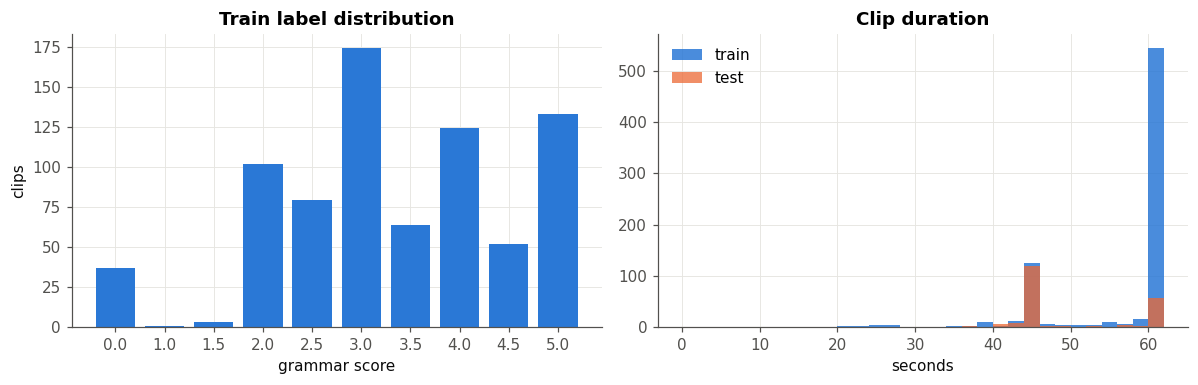

In [2]:
import soundfile as sf
dur = lambda split, names: np.array([sf.info(ROOT / "data" / split / n).duration for n in names])
d_tr, d_te = dur("train", train.filename), dur("test", test.filename)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
vc = train.label.value_counts().sort_index()
ax[0].bar(vc.index.astype(str), vc.values, color=BLUE, width=0.8)
ax[0].set_title("Train label distribution"); ax[0].set_xlabel("grammar score"); ax[0].set_ylabel("clips")
bins = np.arange(0, 64, 2)
ax[1].hist(d_tr, bins=bins, color=BLUE, alpha=0.85, label="train")
ax[1].hist(d_te, bins=bins, color=ORANGE, alpha=0.75, label="test")
ax[1].set_title("Clip duration"); ax[1].set_xlabel("seconds"); ax[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(PLOTS / "eda.png")
print(f"label mean {y.mean():.3f}  std {y.std():.3f}")
print(f"duration median: train {np.median(d_tr):.1f}s, test {np.median(d_te):.1f}s")

**Observations**

* Labels are in half-point steps; 3.0 is the mode; very few 1.0–1.5 clips.
* **37 clips are labelled 0.0**, which is not on the 1–5 rubric. They all have ids 5037–5073
  (every other train id is 0–784; test ids are 0–215), and they are louder recordings: a
  separate batch. The public leaderboard confirms the test set has (almost) none of them: a
  constant prediction of the train mean (3.313) scored **1.005** RMSE, which matches the
  RMSE expected if test labels look like the *non-zero* train clips (1.027) and not like the
  full train set (1.238).
  → The primary CV metric is therefore **RMSE on non-zero clips**. We still keep the 0.0
  clips when training *audio* models (it slightly helped), but text models never see them
  (their transcripts look like ordinary 2–3 answers; the zero is a property of the batch).
* Test clips are shorter (median 45 s vs 60 s) → features are rates, not raw counts.
* `sample_submission.csv` is stale (only 25 of its 204 filenames are test files); the
  submission uses `test.csv`'s 216 rows with the same `filename,label` header.

In [3]:
ids = train.filename.str.extract(r"(\d+)")[0].astype(int)
print("ids of 0.0 clips:", ids[y == 0].min(), "-", ids[y == 0].max(), "| other train ids:",
      ids[y > 0].min(), "-", ids[y > 0].max())
nzl = y[y > 0]
print("expected constant-RMSE if test ~ non-zero train:", round(float(np.sqrt(((nzl - y.mean())**2).mean())), 3),
      "| if test ~ full train:", round(float(np.sqrt(((y - y.mean())**2).mean())), 3), "| observed LB: 1.005")

ids of 0.0 clips: 5037 - 5073 | other train ids: 0 - 784
expected constant-RMSE if test ~ non-zero train: 1.027 | if test ~ full train: 1.238 | observed LB: 1.005


## 3. Preprocessing & transcription

*(The sample-transcript output below is cleared in the public repository for the same reason.)*

`src/transcribe.py` (run once, ~50 min on an RTX 4060, cached to `cache/transcripts.csv`):

* **faster-whisper large-v3**, fp16, beam 5, temperature 0, `language="en"`,
  `word_timestamps=True`, `vad_filter=False` (keep silences so pauses are measurable).
* **Verbatim caveat.** Whisper is trained to output clean text, so it tends to *fix* grammar
  mistakes and drop fillers — erasing the very signal we score. Mitigation: a disfluent,
  ungrammatical `initial_prompt` (*"Umm, so I, I was go to the market and, uh, he don't
  know what- what I am saying."*) which nudges the decoder towards verbatim style. The
  transcripts below keep fillers, repetitions and cut-off words.
* **Repetition loops.** Temperature-0 decoding disables Whisper's own guard, and 71 clips
  (67 train / 4 test) degenerated into loops ("so, so, so, …"). They were detected with the
  same rule for train and test (gzip compression ratio > 2.4, Whisper's own criterion, or
  > 15 immediate repetitions per 100 words) and re-decoded with the guard switched back on
  (temperature fallback, no conditioning on previous text): `fallback == 3`.
* Separate processes: faster-whisper needs CUDA 12 cuBLAS/cuDNN 9, torch here is cu118.

In [ ]:
tr = pd.read_csv(ROOT / "cache" / "transcripts.csv").fillna({"text": ""})
print("transcripts:", len(tr), "| decoding path counts:", tr.fallback.value_counts().to_dict())
d = tr.merge(train, on="filename")
for r in d[d.label > 0].sample(4, random_state=1).itertuples():
    print(f"\n[{r.filename}  label={r.label}]")
    print(textwrap.fill(r.text[:420] + " ...", 110))

## 4. Feature engineering

`src/features.py` computes interpretable features from the transcript and word timestamps:

| group | features | why |
|---|---|---|
| Grammar errors | LanguageTool (en-US) errors per 100 words, by category (GRAMMAR, TYPOS, …) | direct error counts. **Punctuation / casing / typography rules are excluded** – ASR punctuation is produced by Whisper, not by the speaker |
| Fluency | words/min, articulation rate, pause rate & mean length (gaps > 0.5 s), speech ratio | fluent speakers tend to have stronger grammatical control |
| Disfluency | fillers, "like", "you know", immediate repetitions, restarts (repeated 2–3-grams), truncated words | rubric: memorised patterns, incomplete sentences, self-corrections |
| Complexity | sentence length, spaCy dependency-tree depth, subordinate clauses (mark/advcl/ccomp/relcl/xcomp/acl), tense variety, MATTR | rubric: "complex structures handled well" |
| ASR confidence | Whisper avg log-prob, mean word probability, fraction of low-probability words | non-native / ungrammatical speech is harder for the ASR language model |
| CoLA | P(acceptable) per sentence from `textattack/roberta-base-CoLA`: mean, min, % unacceptable | a pretrained grammaticality judge |
| Prosody & timing (`src/round2_b.py`) | pitch (YIN, semitones): std, range, jump std; RMS energy: mean, variation, low-energy share; short pauses (> 0.25 s) per minute; tempo variation over 5 s windows; MTLD; mean dependency distance; fragment share | broken sentences show pitch resets and hesitation; used as their **own** stack component (7) in the alternative submission `final_stack_pw` |

**Length robustness.** Test clips are shorter, so everything is a rate; we use MATTR
(moving-average type–token ratio) instead of TTR, which falls with text length. The
`pearson_duration` column below is a drift check; raw counts (`n_words`, `duration`, …) are
excluded from the models. Correlations use non-zero clips only.

                               pearson_label  spearman_label  pearson_duration  train_mean  test_mean
low_prob_frac                         -0.398          -0.424             0.226       0.069      0.060
lt_err_per100                         -0.263          -0.239             0.058       1.716      1.852
lt_grammar_per100                     -0.230          -0.198            -0.028       0.377      0.422
lt_typos_per100                       -0.216          -0.171             0.040       0.919      0.980
repetition_per100                     -0.214          -0.245             0.031       0.754      0.636
truncated_per100                      -0.201          -0.186            -0.008       0.931      0.886
lt_errors                             -0.199          -0.171             0.125       1.727      1.782
restart_per100                        -0.114          -0.219             0.088       0.482      0.288
filler_per100                         -0.102          -0.074             0.128    

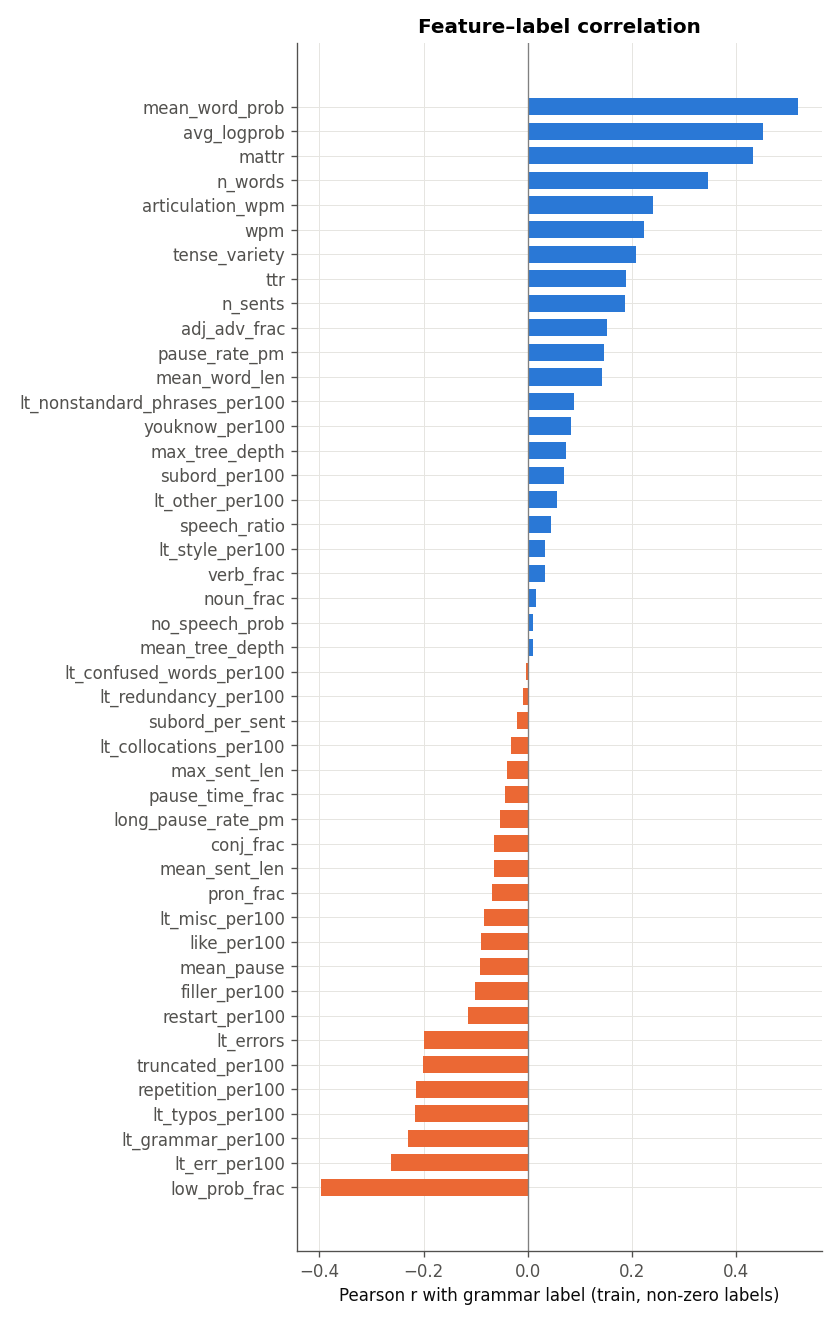

In [5]:
feats = pd.read_csv(ROOT / "cache" / "features.csv")
corr = F.correlation_report(feats, train, PLOTS / "feature_corr.png")
plt.close("all")
from IPython.display import Image, display
display(Image(filename=str(PLOTS / "feature_corr.png"), width=520))

Strongest single signals: Whisper confidence (`mean_word_prob`, r≈0.52), lexical diversity
(MATTR, r≈0.43), number of words spoken in the time (fluency), and LanguageTool error rate
(r≈−0.26). Individually they are weak — no single hand feature explains the score well,
which is why the audio/text representation models matter.

## 5. Models & cross-validation

`train.run_cv` is shared by all models: 5-fold `StratifiedKFold` on the rounded label
(1.x merged into 2 so each class has ≥ 5 members), seed 42, preprocessing inside folds,
`RidgeCV` (alpha by leave-one-out inside the training fold) or `SVR` (RBF, C tuned by an
inner 3-fold grid search – nested CV), predictions clipped to [0, 5]. Test predictions are
the mean of the 5 fold models.

Below, the cheap hand-feature models are re-run live; the embedding models were run by
`src/train.py emb|audio|wavlm_scan`, `src/finetune_text.py` and `src/final.py`, whose
out-of-fold predictions are stored in `cache/preds/` and loaded for the results table.

In [6]:
Htr, Hte, hand_cols = T.hand_features()
for dz in (False, True):
    T.run_cv("ridge_hand", T.ridge, Htr.values, y, Hte.values, drop_zero=dz)
    T.run_cv("lgbm_hand", T.lgbm, Htr.values, y, Hte.values, T.lgbm_es, drop_zero=dz)
# 45 s crop of train AND test (via word timestamps, no re-transcription)
Ctr, Cte, _ = T.hand_features("features_crop45")
T.run_cv("ridge_hand_crop45", T.ridge, Ctr.values, y, Cte.values);

ridge_hand                                    RMSE(non-zero) 0.7904  Pearson(nz) 0.6405  | RMSE(all) 0.8477


lgbm_hand                                     RMSE(non-zero) 0.7932  Pearson(nz) 0.6330  | RMSE(all) 0.8257


ridge_hand_dz                                 RMSE(non-zero) 0.7737  Pearson(nz) 0.6475  | RMSE(all) 0.8849


lgbm_hand_dz                                  RMSE(non-zero) 0.7774  Pearson(nz) 0.6431  | RMSE(all) 0.9761


ridge_hand_crop45                             RMSE(non-zero) 0.7762  Pearson(nz) 0.6483  | RMSE(all) 0.8434


**Layer scans.** Ridge on each layer's pooled vector shows *where* grammar-relevant
information lives. In **WavLM** (self-supervised) it peaks in the upper-middle layers
(base 7–8 of 12; large 18–23 of 24) and drops at the last layer, which specialises in the
pre-training objective. In the **Whisper** encoder it keeps improving almost to the top
(best 29–31 of 32): Whisper is trained to feed a transcription decoder, so its useful
linguistic information accumulates towards the end. We use WavLM-large L18–23 and Whisper
L29–31.

In [7]:
scan = []
for name, n in [("wavlm", 13), ("wavlm_large", 25), ("whisper_layers", 33)]:
    for L in range(n):
        p = T.PREDS / f"ridge_{name}_L{L}.npz"
        if p.exists():
            z = np.load(p); scan.append((name, L, T.metrics(z["oof"], z["y"])["rmse_nz"]))
scan = pd.DataFrame(scan, columns=["model", "layer", "rmse_nz"])
labels = {"wavlm": "WavLM-base+", "wavlm_large": "WavLM-large", "whisper_layers": "Whisper-large-v3 enc."}
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for (name, g), c in zip(scan.groupby("model", sort=False), [BLUE, ORANGE, "#1baf7a"]):
    ax.plot(g.layer / g.layer.max(), g.rmse_nz, "-o", color=c, lw=2, ms=3.5, label=labels[name])
ax.set_xlabel("relative layer depth (0 = input features, 1 = last layer)")
ax.set_ylabel("OOF RMSE (non-zero)"); ax.set_title("Ridge on a single encoder layer")
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(PLOTS / "encoder_layers.png")

## 6. Results: every model, same folds

`rmse_nz` / `pearson_nz` = on the 732 non-zero clips (test-like, **primary**);
`rmse_all` includes the 37 zero clips. Suffix `_dz` = trained without the zero clips.

In [8]:
import re
skip = re.compile(r"(_L\d+$)|(^final)|(_s\d$)|(^ridge_wavlm.*_L\d)")   # layer scans, seeds, blends
rows = []
for p in sorted(T.PREDS.glob("*.npz")):
    if skip.search(p.stem):
        continue
    z = np.load(p)
    rows.append({"model": p.stem, **T.metrics(z["oof"], z["y"])})
results = pd.DataFrame(rows).sort_values("rmse_nz").reset_index(drop=True)
pd.set_option("display.precision", 4); pd.set_option("display.max_rows", 80)
results

,model,rmse_nz,pearson_nz,rmse_all
0,svr_all_wl,0.4859,0.8789,0.5015
1,svr_all_hub,0.4865,0.8786,0.4930
2,svr_all_tuned,0.4888,0.8765,0.4856
3,svr_all_ts,0.4895,0.8770,0.5027
4,svr_all_r2,0.4905,0.8766,0.5051
...,...,...,...,...
86,ridge_r2_prosody_dz,0.9411,0.3717,1.3866
87,ridge_r2_text_dz,0.9515,0.3453,1.1923
88,ridge_r2_prosody_relative_dz,0.9538,0.3391,1.2540
89,ridge_errtype_dz,0.9685,0.2954,1.2239


### Validation design: what the test set really looks like

Four findings changed how models were chosen (details in `EXPERIMENTS.md`):

1. **0.0 batch** (section 2): absent from test → primary metric on non-zero clips.
2. **Short clips.** Train clips of 40–50 s score lower (mean 3.06 vs 3.58 for 60 s clips) and
   141 of 216 test clips are 40–50 s. Nested CV on short (< 50 s) training clips predicted the
   public-leaderboard **order of every submission**; all-clip CV sometimes pointed the wrong way.
3. **Prompt shift.** Clustering transcripts (labels unused) shows about half the test answers
   prompts that are rare or absent in train. Prompt-held-out CV reveals that frozen text
   embeddings learn topic shortcuts (DeBERTa Ridge 0.602 → 0.664), while the fine-tuned
   RoBERTa-CoLA learned grammar (0.684 → ~0.69) and audio is robust.
4. **Repeated speakers.** Low-layer WavLM voice embeddings show ~30% of train clips share a
   voice with another clip (labels nearly identical), but no test speaker appears in train.
   Speaker-grouped CV inflates audio models by 0.03–0.04, yet the final stack's weights stay
   the best ones even when scored on unseen speakers only.

In [9]:
rows = []
for name in STACK_COMPONENTS:
    r = {"component": name}
    for mode, folder in [("random folds", "preds"), ("prompt-held-out", "preds_g"), ("speaker-grouped", "preds_s")]:
        p = ROOT / "cache" / folder / f"{name}.npz"
        r[mode] = T.metrics(np.load(p)["oof"], y)["rmse_nz"] if p.exists() else np.nan
    rows.append(r)
pd.DataFrame(rows).set_index("component").round(4)

,random folds,prompt-held-out,speaker-grouped
component,,,
svr_all,0.4906,0.5071,0.5051
svr_wavlm_large,0.5168,0.5203,0.5539
ridge_deb_hand_dz,0.6016,0.6638,0.6062
ft_roberta,0.6842,0.6840,0.6851
attnpool_wavlmL,0.5635,0.5768,0.5827
svr_whisperL29_31,0.5265,0.5235,0.5564
ridge_r2w_dz,0.8665,0.8737,0.8675


### Final model: duration-aware Ridge stack (`src/stack.py`)

Each clip gets 6 component predictions (out-of-fold), plus its duration (clamped to the
training range 20–61 s so nothing extrapolates), words per minute and Whisper mean word
confidence, plus **prediction × duration** interactions. A Ridge regression (α chosen by
internal CV) maps these to the score, trained on the 732 non-zero clips.

The interactions let the stacker re-weight components by answer length: on **short answers it
trusts the fine-tuned text model more and the pooled audio SVRs less**, because a short clip
gives the audio summary less to average over while the transcript still shows grammar.
Reported CV is **nested** (the stacker never sees the clips it is scored on).

In [10]:
rep = json.loads((ROOT / "cache" / f"{FINAL}_report.json").read_text())
print("stack components:", rep["components"])
print(f"Ridge alpha: {rep['alpha']:.2f}")
print(f"nested CV RMSE (non-zero): {rep['nested_rmse_nz']:.4f} | short clips: {rep['nested_rmse_short']:.4f}"
      f" | long clips: {rep['nested_rmse_long']:.4f}")
alt = json.loads((ROOT / "cache" / f"{ALT}_report.json").read_text())
print(f"alternative {ALT} (+ prosody/timing component): nested {alt['nested_rmse_nz']:.4f} | "
      f"short clips {alt['nested_rmse_short']:.4f} | training {alt['train_insample']['rmse_nz']:.4f}")
pd.Series(rep["coef"]).round(3).to_frame("Ridge coefficient")

stack components: ['svr_all', 'svr_wavlm_large', 'ridge_deb_hand_dz', 'ft_roberta', 'attnpool_wavlmL', 'svr_whisperL29_31']
Ridge alpha: 31.62
nested CV RMSE (non-zero): 0.4637 | short clips: 0.5052 | long clips: 0.4496
alternative final_stack_pw (+ prosody/timing component): nested 0.4611 | short clips 0.4973 | training 0.1385


,Ridge coefficient
svr_all,0.201
svr_wavlm_large,0.254
ridge_deb_hand_dz,0.122
ft_roberta,0.169
attnpool_wavlmL,0.147
svr_whisperL29_31,0.217
duration,0.006
wpm,-0.000
mean_word_prob,0.020
svr_all*dur,0.052


## 7. TRAINING RMSE (compulsory)

In [11]:
fin = np.load(T.PREDS / f"{FINAL}.npz")      # oof = nested out-of-fold stack predictions
ins_m = rep["train_insample"]
nzm = y > 0
print("=" * 72)
print(f"TRAINING RMSE (in-sample: stack applied to components refit on the full train set)")
print(f"    {ins_m['rmse_nz']:.4f} on the 732 non-zero clips")
print(f"CROSS-VALIDATED RMSE (nested 5-fold out-of-fold)")
print(f"    {T.rmse(fin['oof'][nzm], y[nzm]):.4f} on the 732 non-zero clips "
      f"(short clips {rep['nested_rmse_short']:.4f})")
print(f"PUBLIC LEADERBOARD RMSE: {LB.get(FINAL, 'n/a')}")
print("=" * 72)

TRAINING RMSE (in-sample: stack applied to components refit on the full train set)
    0.1370 on the 732 non-zero clips
CROSS-VALIDATED RMSE (nested 5-fold out-of-fold)
    0.4637 on the 732 non-zero clips (short clips 0.5052)
PUBLIC LEADERBOARD RMSE: 0.3432


**Why the gap?** The training RMSE is measured on clips the models were fitted on, so it is
optimistic: an RBF-SVR on thousands of embedding dimensions and a fine-tuned transformer can
nearly memorise 769 clips (the SVR fits most points to within its ε-tube). The OOF RMSE
scores each clip with models that never saw it, so it is the honest estimate of test
performance and is what all model choices were based on. A large train/OOF gap is expected
with high-dimensional features and a small dataset; the regularisation (SVR C, Ridge α, fixed
fine-tuning epochs) is tuned on validation folds, not on training error. The irreducible
part of the OOF error also includes label noise (human MOS ratings in 0.5 steps).

## 8. Visualisations

In [12]:
# The stack is trained and evaluated on the 732 non-zero clips (the 0.0 batch is not in test).
nz = y > 0
short_tr = pd.read_csv(ROOT / "cache" / "features.csv").pipe(
    lambda f: train[["filename"]].merge(f[f.split == "train"], how="left")).duration.values < 50
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
jit = np.random.default_rng(0).normal(0, 0.06, len(y))
for m, c, lab in [(nz & ~short_tr, BLUE, "clips >= 50 s"), (nz & short_tr, ORANGE, "clips < 50 s")]:
    ax[0].scatter(y[m] + jit[m], fin["oof"][m], s=10, color=c, alpha=0.55, lw=0, label=lab)
ax[0].plot([1, 5], [1, 5], color=MUTED, lw=1, ls="--")
ax[0].set_xlabel("true score (jittered)"); ax[0].set_ylabel("nested OOF prediction")
ax[0].set_title("Predicted vs actual (out-of-fold)"); ax[0].legend(frameon=False, loc="upper left")
res = fin["oof"] - y
labs = np.sort(np.unique(y[nz]))
ax[1].boxplot([res[nz & (y == l)] for l in labs], labels=[str(l) for l in labs], widths=0.6,
              medianprops=dict(color=ORANGE, lw=2), flierprops=dict(ms=3, markeredgecolor=MUTED))
ax[1].axhline(0, color=MUTED, lw=1)
ax[1].set_xlabel("true score"); ax[1].set_ylabel("residual (pred − true)")
ax[1].set_title("Residuals by true label")
fig.tight_layout(); fig.savefig(PLOTS / "oof_scatter_residuals.png")

Residuals trend from positive (low true scores over-predicted) to negative (5.0
under-predicted): regression to the mean, which is the RMSE-optimal behaviour under
uncertainty (we checked calibration: the slope of true-on-predicted is 1.01–1.04 in every
duration bin, so no extra stretching is warranted). The sparse 1.0–1.5 clips are the worst
predicted.

In [13]:
# Interpretability: which hand-crafted features matter (models trained on non-zero clips)
from lightgbm import LGBMRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
Xh, yh = Htr.values[nz], y[nz]
lg = LGBMRegressor(n_estimators=400, learning_rate=0.03, num_leaves=15, min_child_samples=20,
                   subsample=0.8, subsample_freq=1, colsample_bytree=0.7, verbose=-1,
                   importance_type="gain", random_state=42).fit(Xh, yh)
rg = RidgeCV(alphas=T.ALPHAS).fit(StandardScaler().fit_transform(Xh), yh)
imp = pd.DataFrame({"lgbm_gain": lg.feature_importances_ / lg.feature_importances_.sum(),
                    "ridge_coef": rg.coef_}, index=hand_cols)
top = imp.sort_values("lgbm_gain").tail(15)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
ax[0].barh(top.index, top.lgbm_gain, color=BLUE, height=0.7); ax[0].set_title("LightGBM gain share")
ax[1].barh(top.index, top.ridge_coef, color=np.where(top.ridge_coef > 0, BLUE, ORANGE), height=0.7)
ax[1].axvline(0, color=MUTED, lw=1); ax[1].set_title("Ridge coefficient (standardised)")
fig.tight_layout(); fig.savefig(PLOTS / "feature_importance.png")

Both views agree that **ASR confidence** (`mean_word_prob`, `avg_logprob`) and **lexical
diversity** (MATTR) carry most of the hand-feature signal, followed by fluency (rate, pauses).
Ridge coefficients are *conditional* on the other features: `low_prob_frac` gets a positive
coefficient despite a negative correlation because it is strongly collinear with
`mean_word_prob` – read the sign of a single coefficient with care.

## 9. Error analysis: worst-predicted (non-zero) clips

*Transcript-printing outputs are cleared in the public repository (competition data must not
be shared); run the notebook locally to see them.*

In [ ]:
ea = train.assign(pred=fin["oof"], err=fin["oof"] - y).merge(
    tr[["filename", "text", "avg_logprob", "duration"]], on="filename")
ea = ea[ea.label > 0].reindex(ea[ea.label > 0].err.abs().sort_values(ascending=False).index)
for r in ea.head(6).itertuples():
    print(f"\n[{r.filename}] true {r.label}  pred {r.pred:.2f}  dur {r.duration:.0f}s  "
          f"logprob {r.avg_logprob:.2f}  words {len(r.text.split())}")
    print(textwrap.fill(r.text[:380] + " ...", 110))

**What goes wrong (typical patterns)**

* **Very short / off-task answers** (a sentence or two): little evidence, so models fall back
  to the mean; the human rater could still judge the few sentences harshly or kindly.
* **Memorised / scripted answers.** Several large over-predictions are polished, essay-like
  texts (e.g. a textbook-style description of a childhood playground, true 1.0, predicted
  2.4; a brochure-like "best day of my life" story, true 3.0, predicted 4.5). The rubric's level 1 explicitly mentions *memorised patterns*: raters
  penalise recited text, while our models reward its fluency and vocabulary. Detecting
  "read-aloud" prosody or off-prompt content would be a valuable next feature.
* **Fluent-sounding but grammatically weak** (or the reverse): the audio models (largest
  blend weight) partly score *fluency/accent*; when fluency and grammar disagree, errors grow.
* **ASR cleanup**: Whisper still normalises some errors ("he go" → "he goes"), so text
  features under-count mistakes for weaker speakers.
* **Rare labels**: only 4 clips at 1.0–1.5; predictions for them are pulled up towards 2.5.
* Some labels look inconsistent with the transcript – human MOS labels are noisy.

## 10. Conclusions, limitations, future work

**Results path (public leaderboard RMSE)**

| submission | change | public LB |
|---|---|---|
| constant mean | baseline | 1.0050 |
| v1 | weighted blend of 4 models + linear stretch | 0.3529 |
| v2 | + attention pooling over WavLM frames | 0.3507 |
| stack | duration-aware Ridge stack | 0.3440 |
| **stack + Whisper L29–31 (`final_stack_w`, final)** | **+ SVR on Whisper's upper encoder layers** | **0.3432** |
| alternative (`final_stack_pw`, also selected) | + Ridge on pitch, energy, pause, tempo, lexical and syntax features: best CV (short clips 0.5052 → 0.4973, gain held on prompt-held-out and unseen-speaker CV) | lower than 0.3432 |

Both are selected for the final (private) ranking: `final_stack_w` has the best public score,
`final_stack_pw` the best cross-validation. With ~130 public clips (±0.02 noise) the two can
swap order on the hidden 40%.

**Conclusions**
* Frozen self-supervised **speech representations** are the strongest signal (WavLM-large
  L18–23 and Whisper L29–31, ~0.52–0.53 RMSE alone); a joint SVR over audio + text + hand
  features is the best single model (0.491).
* **Transcript models** are weaker alone but complementary. Only the *fine-tuned* grammar model
  (RoBERTa-CoLA) is robust to unseen prompts; frozen embeddings partly learn topic.
* **Validation design mattered more than model choice**: finding the 0.0 batch, the short-clip
  effect, the prompt shift and repeated speakers decided what was kept.
* **Diversity beats strength in the ensemble**: RoBERTa-large was a better model alone (short
  clips 0.621 vs 0.688) but made the stack worse because it overlapped with the joint SVR.

**Tried and rejected (all with honest nested / short-clip CV)**

| idea | result |
|---|---|
| fine-tuning DeBERTa-v3 | diverged (NaN, then collapse) on this setup |
| fine-tuning WavLM top 8 layers (6 / 10 epochs) | 0.559 / 0.533 alone; no stack gain |
| crop augmentation + test-time averaging | 0.522 alone; no gain |
| nested SVR hyper-parameter tuning | worse (fitted noise) |
| "what did Whisper fix?" diff features, LLM judge (Qwen2.5-3B) | real but redundant signal |
| stack weights learned on prompt-held-out folds | LB 0.3522 (worse) |
| importance weighting of short clips, gating by prompt novelty | no gain (test prompts are more novel than any training clip, so trust cannot be learned) |
| grammar error-type features, ordinal regression | no gain |
| RoBERTa-large-CoLA (3 seeds) | best text model alone, worse in the stack |
| HuBERT-large, repeated-CV bagging, train+test scaling, pseudo-labels | no stack gain under the paired rule |
| LoRA fine-tune of Whisper's top 8 encoder layers (3 seeds) | 0.526 alone; borderline in the stack (7/8, gain within noise); LB 0.3447 |
| shrinking novel-prompt clips, duration clipping, quantile alignment | no gain / worse |
| Huber, Bayesian Ridge, LightGBM stackers; KNN neighbour features; mid-fusion MLP | no gain |
| Whisper decoder entropy | r = −0.52 alone, but redundant with ASR confidence |
| w2v-BERT 2.0, literal CTC transcript + cross-ASR disagreement, NNLS / batch-specific stackers | no gain (cross-ASR helped only on unseen prompts) |

**Limitations**
* ASR errors and Whisper's normalisation of ungrammatical speech; word timestamps are coarse.
* Small data (769 clips, 4 at the bottom of the scale) → high variance, regression to the mean.
* Label noise (single MOS score per clip, 0.5 steps).
* Audio features may capture accent/recording conditions, not only grammar.

* Public LB is ~130 clips: about ±0.02 of noise, larger than most recent gains.

**Future work**
* More labelled data on the *test* prompts and shorter task; prompt-aware evaluation.
* A verbatim-trained ASR (or multiple hypotheses) to stop Whisper normalising errors.
* Detecting memorised / read-aloud answers (the largest error source in section 9).
* Speaker-independent audio representations (the speaker leak shows identity is encoded).

## 11. Generating `submission.csv`

In [15]:
sub = test[["filename"]].copy()
sub["label"] = np.clip(fin["test"], 0, 5)
assert len(sub) == 216 and sub.label.between(0, 5).all() and sub.filename.is_unique
sub.to_csv(ROOT / "submissions" / "submission.csv", index=False)
print(sub.label.describe().round(3).to_string())
sub.head()

count    216.000
mean       3.247
std        0.846
min        1.833
25%        2.586
50%        3.154
75%        3.772
max        5.000


,filename,label
0,audio_128.wav,2.9167
1,audio_156.wav,4.1139
2,audio_19.wav,4.5292
3,audio_108.wav,2.0080
4,audio_206.wav,2.0309
